In [1]:
from pathlib import Path
from typing import List, Tuple

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms

In [2]:
from pathlib import Path
from PIL import Image
import torch
from torchvision import models


# -------- Model --------
def load_backbone(device):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model = models.mobilenet_v3_small(weights=weights)
    model.eval().to(device)
    return model

# -------- Preprocessing --------
def build_transform():
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    return weights.transforms()


# -------- Image loader --------
def list_images(root_dir):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in Path(root_dir).rglob("*") if p.suffix.lower() in exts]


# -------- Feature extraction --------
@torch.no_grad()
def extract_feature_maps(image_dir, batch_size=16, device=None,upto=-1):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    backbone = load_backbone(device)
    transform = build_transform()

    image_paths = list_images(image_dir)
    if upto!=-1:
        image_paths=image_paths[:upto]
    all_feats = []
    all_paths = []

    batch = []
    batch_paths = []

    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB")
            x = transform(img)
            batch.append(x)
            batch_paths.append(str(path))
        except:
            print(f'[img] failed')
            continue

        if len(batch) == batch_size:
            feats = run_batch(backbone, batch, device)
            all_feats.append(feats)
            all_paths.extend(batch_paths)
            batch, batch_paths = [], []

    if batch:
        feats = run_batch(backbone, batch, device)
        all_feats.append(feats)
        all_paths.extend(batch_paths)

    # 🔥 keep everything as torch tensors
    features = torch.cat(all_feats, dim=0)  # (N, 576, 7, 7)

    return all_paths, features


def run_batch(backbone, batch, device):
    x = torch.stack(batch).to(device)
    feats = backbone.features(x)  # (B, 576, 7, 7)
    return feats.cpu()   # keep as tensor



In [3]:
cat_paths, cat_features = extract_feature_maps("./image_demo/PetImages/Cat/", batch_size=1,upto=100)
dog_paths, dog_features = extract_feature_maps("./image_demo/PetImages/Dog/", batch_size=1,upto=100)


/opt/miniconda3/envs/kai/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:890: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [4]:
import rot_class as rot

In [5]:
transforms.CenterCrop([224])

CenterCrop(size=(224, 224))

In [6]:
cat_features.shape

torch.Size([100, 576, 7, 7])

In [7]:
model=rot.RoT_image(2,(576,7,7))

In [8]:
features=torch.concat((cat_features,dog_features),0)
labels=torch.zeros(200,dtype=int)
labels[:100]=1

In [9]:
model.fit(features,labels,500,batch_size=20)

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.Size([20])
SUPER

points.shape=torch.Size([20, 576, 7, 7])
response.shape=torch.Size([20, 2])
target.shape=torch.S

In [10]:
model.predict(features)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

In [11]:
importances=model.importance(features)

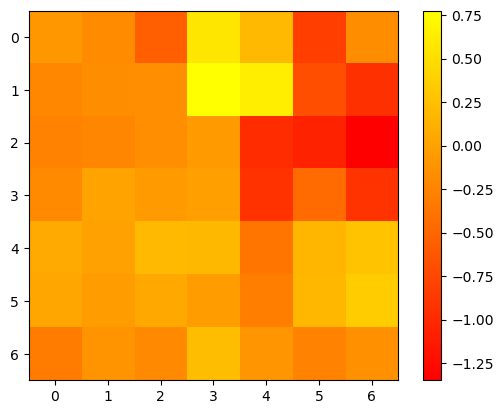

In [12]:
from matplotlib import pyplot as plt
plt.imshow(importances[0,0].sum(0).detach().numpy(),cmap='autumn',origin='upper')

plt.colorbar()

In [50]:
paths=cat_paths+dog_paths
import seaborn
offset=90
cmap=seaborn.diverging_palette(offset, offset+180,  n=70, center="dark",as_cmap=True)

def plot_im(i):
    heat=importances[i,0].sum(0).detach().numpy()
    img = transforms.CenterCrop([224])(Image.open(paths[i]).convert("RGB"))
    plt.imshow(img,extent=[0, 1, 0, 1])
    plt.imshow(heat,cmap=cmap,origin='upper',extent=[0, 1, 0, 1],interpolation='bicubic',vmax=max(heat.max(),-heat.min()),vmin=min(-heat.max(),heat.min()),alpha=0.8)
    plt.colorbar()


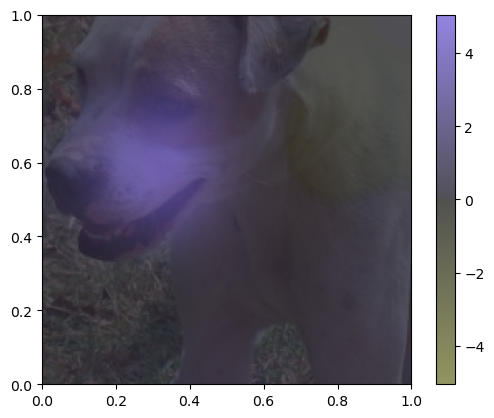

In [51]:
plot_im(150)

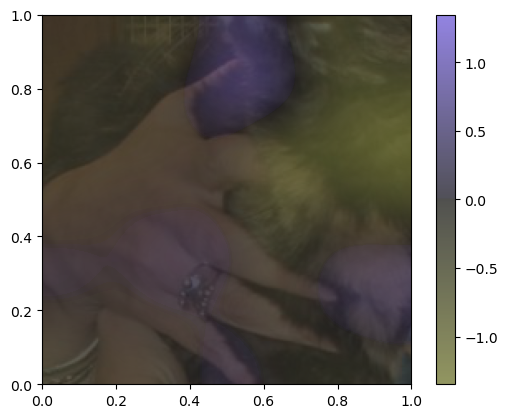

In [53]:
plot_im(0)

In [ ]:
paths=cat_paths+dog_paths
import seaborn
offset=90
cmap=seaborn.diverging_palette(offset, offset+180,  n=70, center="dark",as_cmap=True)

def plot_im(i):
    heat=importances[i,0].sum(0).detach().numpy()
    img = transforms.CenterCrop([224])(transforms.Resize(255)(Image.open(paths[i]).convert("RGB")))
    plt.imshow(img,extent=[0, 1, 0, 1])
    plt.imshow(heat,cmap=cmap,origin='upper',extent=[0, 1, 0, 1],interpolation='bicubic',vmax=max(heat.max(),-heat.min()),vmin=min(-heat.max(),heat.min()),alpha=0.8)
    plt.colorbar()

In [ ]:
plot_im(150)


: 

In [ ]:
plot_im(0)

: 